### 21) Partial Autocorrelation (PACF)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf
import seaborn as sns

In [6]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data['time'] = pd.to_datetime(data['time'])
data = data.sort_values('time')
data.set_index('time', inplace=True)

In [ ]:
pm25 = data['pm2_5']
pm25_diff = pm25.diff().dropna()
pm25_seasonal = pm25.diff(24).dropna()       
pm25_both = pm25.diff().diff(24).dropna() 

The pm2.5 data is seasonal (non-stationary).
PACF/ACF plots are only meaningful if the statistical properties of the series (mean, variance, autocorrelation structure) stay constant over time.

Differencing removes the systematic, predictable part of the series (the trend or the repeating cycle) and leaving behind the part that isn't explained by the trend/seasonality. The output is closer to a stationary process: fluctuating around a constant mean, without a systematic or periodic pattern.

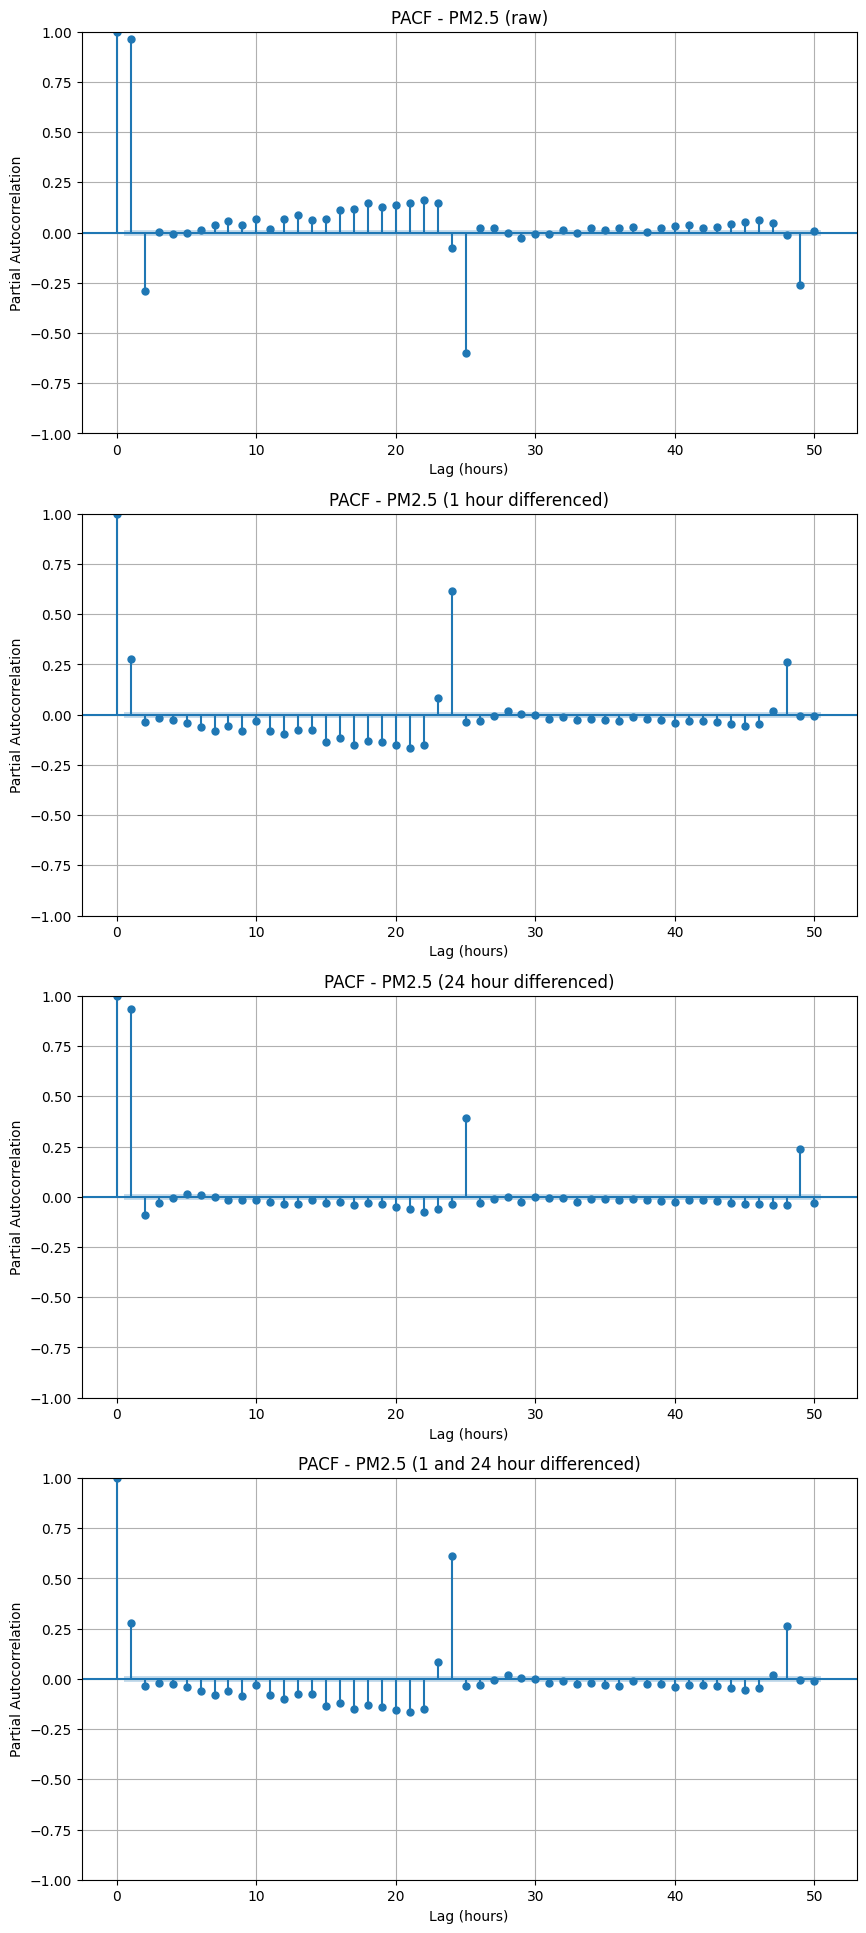

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(10, 24))

plot_pacf(pm25, lags=50, method='ywm', alpha=0.05, ax=axes[0])
axes[0].set_title('PACF - PM2.5 (raw)')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Partial Autocorrelation')
axes[0].grid(True)

plot_pacf(pm25_diff, lags=50, method='ywm', ax=axes[1])
axes[1].set_title('PACF - PM2.5 (1 hour differenced)')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].grid(True)

plot_pacf(pm25_seasonal, lags=50, method='ywm', ax=axes[2])
axes[2].set_title('PACF - PM2.5 (24 hour differenced)')
axes[2].set_xlabel('Lag (hours)')
axes[2].set_ylabel('Partial Autocorrelation')
axes[2].grid(True)

plot_pacf(pm25_diff, lags=50, method='ywm', ax=axes[3])
axes[3].set_title('PACF - PM2.5 (1 and 24 hour differenced)')
axes[3].set_xlabel('Lag (hours)')
axes[3].set_ylabel('Partial Autocorrelation')
axes[3].grid(True)

plt.show()

**Insights:**

The present pm2.5 data has high direct correlation(without any intermediate effects) with the pm2.5 data of the previous day at the same time. Similarly, the pm2.5 data of previous hour and pm2.5 data of 2 days before also show mild direct correlation.

### 22. Lag Correlation Analysis


In [17]:
lags = np.arange(1,169, 1)

for lag in lags:
    data[f'pm2_5_lag_{lag}'] = data['pm2_5'].shift(lag)

correlations = {}

for lag in lags:
    corr = data['pm2_5'].corr(data[f'pm2_5_lag_{lag}'])
    correlations[lag] = corr
    
corr_df = pd.DataFrame({
    'Lag (hours)': correlations.keys(),
    'Correlation': correlations.values()
})

corr_df = corr_df.sort_values('Lag (hours)')

/tmp/ipykernel_8866/1119919424.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'pm2_5_lag_{lag}'] = data['pm2_5'].shift(lag)


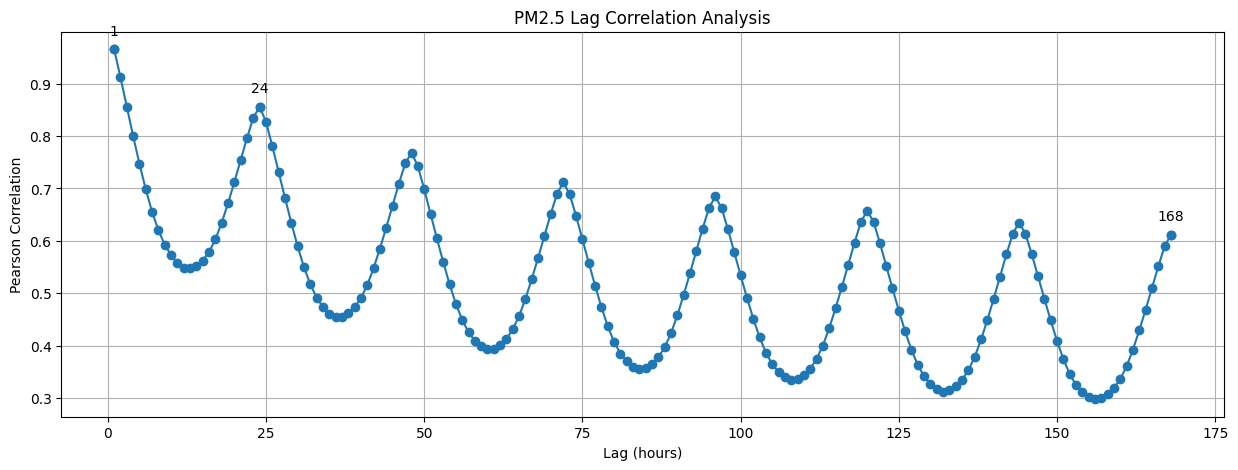

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    corr_df['Lag (hours)'],
    corr_df['Correlation'],
    marker='o',
    # markersize=3,
    # linewidth=1
)


highlight_lags = [1, 24, 168]
highlight_data = corr_df[corr_df['Lag (hours)'].isin(highlight_lags)]

plt.scatter(
    highlight_data['Lag (hours)'],
    highlight_data['Correlation'],
    # s=20,
    zorder=5,
)

# Add labels
for _, row in highlight_data.iterrows():
    plt.annotate(
        f"{int(row['Lag (hours)'])}",
        (row['Lag (hours)'], row['Correlation']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

plt.xlabel('Lag (hours)')
plt.ylabel('Pearson Correlation')
plt.title('PM2.5 Lag Correlation Analysis')
plt.grid(True)
plt.show()

From the lag correlation analysis, we can see the pm2.5 data shows a diurnal (24-hour) cycle.

It doesn't have high weekly correlations as compared to high 24-hour correlation.

### 23. Cross-Correlation Analysis


In [ ]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

# Convert time column to datetime
data['time'] = pd.to_datetime(data['time'])
data = data.sort_values('time').set_index('time')

In [15]:
target = 'pm2_5'
weather_vars = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_direction_10m',
    'surface_pressure'
]
MAX_LAG = 48

In [16]:
def cross_correlation(series_x, series_y, max_lag):
   
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []

    for lag in lags:
        if lag < 0:
            corr = series_x[:lag].corr(series_y[-lag:])
        elif lag > 0:
            corr = series_x[lag:].corr(series_y[:-lag])
        else:
            corr = series_x.corr(series_y)

        correlations.append(corr)

    return lags, correlations

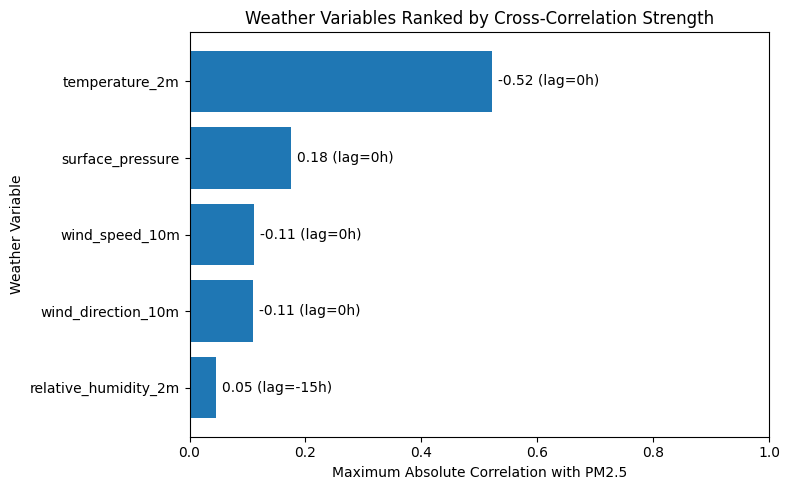

In [17]:
results = []

for var in weather_vars:

    lags, corrs = cross_correlation(
        data[target],
        data[var],
        MAX_LAG
    )

    best_idx = np.nanargmax(np.abs(corrs))

    results.append({
        "Variable": var,
        "Best Lag": lags[best_idx],
        "Correlation": corrs[best_idx],
        "Abs Correlation": abs(corrs[best_idx])
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Abs Correlation", ascending=True)
)

plt.figure(figsize=(8,5))

bars = plt.barh(
    results_df["Variable"],
    results_df["Abs Correlation"]
)

# Add correlation values on bars
for bar, corr, lag in zip(
    bars,
    results_df["Correlation"],
    results_df["Best Lag"]
):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{corr:.2f} (lag={lag}h)",
        va="center"
    )

plt.xlabel("Maximum Absolute Correlation with PM2.5")
plt.ylabel("Weather Variable")
plt.title("Weather Variables Ranked by Cross-Correlation Strength")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

The strongest correlation of a Weather Variable with PM 2.5 is Tempreature at -0.52 (lag = 0hour).
This indicates that there is a strong inverse correlation between PM2.5 and Tempreature.
This can be explained by the seasonal patterns in Kathmandu Valley which is highly polluted in winters when tempreature is lower and is less polluted in summers and monsoon when the tempreature is higher.


temperature_2m
Strongest Absolute Correlation = -0.523
Best lag = 0 hours

relative_humidity_2m
Strongest Absolute Correlation = 0.046
Best lag = -15 hours

wind_speed_10m
Strongest Absolute Correlation = -0.111
Best lag = 0 hours

wind_direction_10m
Strongest Absolute Correlation = -0.109
Best lag = 0 hours

surface_pressure
Strongest Absolute Correlation = 0.176
Best lag = 0 hours


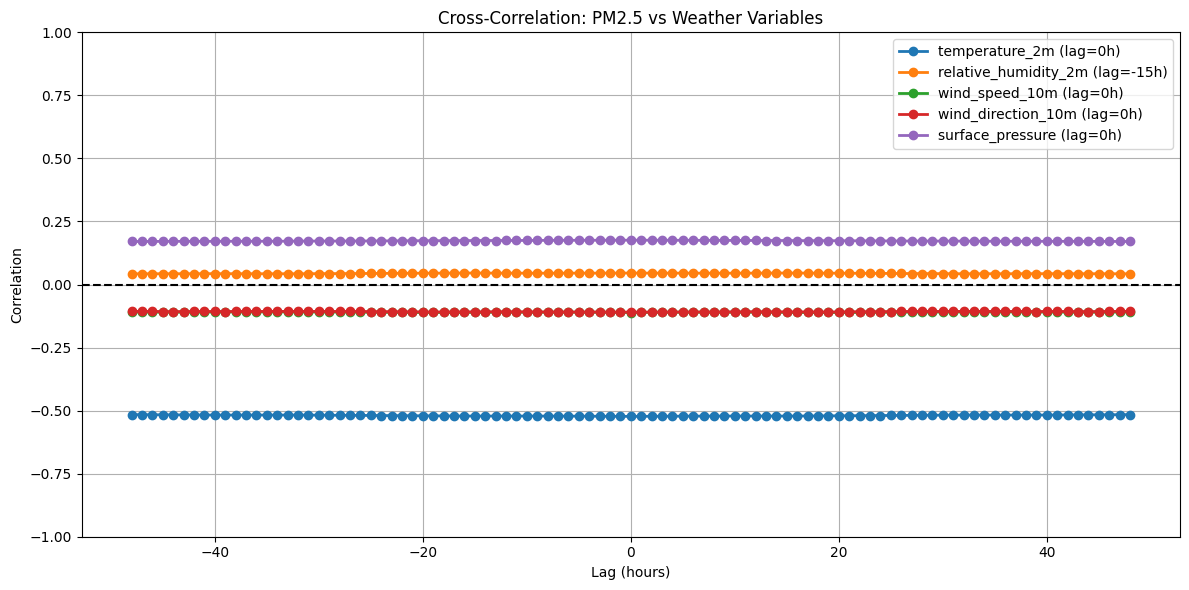

In [ ]:
plt.figure(figsize=(12, 6))

for var in weather_vars:

    lags, corrs = cross_correlation(
        data[target],
        data[var],
        MAX_LAG
    )

    best_idx = np.nanargmax(np.abs(corrs))
    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]

    print(f"\n{var}")
    print(f"Strongest Absolute Correlation = {best_corr:.3f}")
    print(f"Best lag = {best_lag} hours")

    plt.plot(
        lags,
        corrs,
        marker='o',
        linewidth=2,
        label=f"{var} (lag={best_lag}h)"
    )

plt.axhline(0, color='black', linestyle='--')
plt.ylim(-1, 1)

plt.title('Cross-Correlation: PM2.5 vs Weather Variables')
plt.xlabel('Lag (hours)')
plt.ylabel('Correlation')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()